<a href="https://www.kaggle.com/code/sonawanelalitsunil/heart-risk-in-china-ml-99-37?scriptVersionId=225831498" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.xls
/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv


## Title:
### 🚨 "Heart Attack Risk Analysis in China: Exploring Key Health & Lifestyle Factors"



#### Detailed Description:
🏥 Overview
The Heart Attack Risk Dataset of China provides valuable insights into cardiovascular health, focusing on risk factors, symptoms, and lifestyle habits that contribute to heart disease. Given the increasing prevalence of heart attacks due to urbanization, dietary changes, and sedentary lifestyles, this dataset is crucial for understanding trends and developing predictive models.

📊 Dataset Features
The dataset includes 19 key features, covering symptoms, medical history, and lifestyle choices:

##### Symptoms:

Chest_Pain – Common heart attack symptom.

Shortness_of_Breath – Difficulty in breathing, often linked to heart conditions.

Fatigue – Extreme tiredness, indicating poor heart function.

Palpitations – Irregular heartbeat.

Dizziness – Can result from low blood supply to the brain.

Swelling – Often due to fluid retention from heart failure.

Pain_Arms_Jaw_Back – Radiating pain, a strong heart attack indicator.

Cold_Sweats_Nausea – Sudden sweating and nausea linked to cardiac distress.

##### Medical Conditions & Risk Factors:

High_BP (High Blood Pressure) – A leading cause of heart disease.

High_Cholesterol – Excess cholesterol leads to artery blockages.

Diabetes – A chronic disease that significantly increases heart attack risk.

##### Lifestyle Factors:

Smoking – Increases risk by damaging blood vessels.

Obesity – Leads to high cholesterol, high BP, and diabetes.

Sedentary_Lifestyle – Lack of physical activity, leading to poor cardiovascular health.

Chronic_Stress – Affects heart health by increasing BP and inflammation.

##### Genetic & Demographic Factors:

Family_History – Genetic predisposition to heart disease.
Gender – Heart attack risk varies between men and women.
Age – Older individuals face higher risks.
Target Variable:

##### Heart_Risk – The binary classification (0 = Low Risk, 1 = High Risk) indicating heart attack likelihood.


## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv('/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv')

In [4]:
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [5]:
df.tail()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
69995,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,30.0,0.0
69996,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,56.0,1.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,53.0,0.0
69998,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,57.0,1.0
69999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,51.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [7]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


In [8]:
df.corr

<bound method DataFrame.corr of        Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0             0.0                  0.0      0.0           1.0        0.0   
1             0.0                  1.0      0.0           1.0        0.0   
2             1.0                  0.0      0.0           1.0        0.0   
3             1.0                  1.0      0.0           1.0        0.0   
4             0.0                  0.0      1.0           0.0        1.0   
...           ...                  ...      ...           ...        ...   
69995         0.0                  0.0      1.0           0.0        0.0   
69996         1.0                  1.0      1.0           0.0        1.0   
69997         0.0                  0.0      0.0           0.0        0.0   
69998         1.0                  1.0      0.0           1.0        1.0   
69999         1.0                  1.0      1.0           1.0        1.0   

       Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea

In [9]:
df.dtypes

Chest_Pain             float64
Shortness_of_Breath    float64
Fatigue                float64
Palpitations           float64
Dizziness              float64
Swelling               float64
Pain_Arms_Jaw_Back     float64
Cold_Sweats_Nausea     float64
High_BP                float64
High_Cholesterol       float64
Diabetes               float64
Smoking                float64
Obesity                float64
Sedentary_Lifestyle    float64
Family_History         float64
Chronic_Stress         float64
Gender                 float64
Age                    float64
Heart_Risk             float64
dtype: object

In [10]:
df.isnull().sum()

Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64

In [11]:
df.duplicated().sum()

6245

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

0

In [14]:
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

## Data visualizations

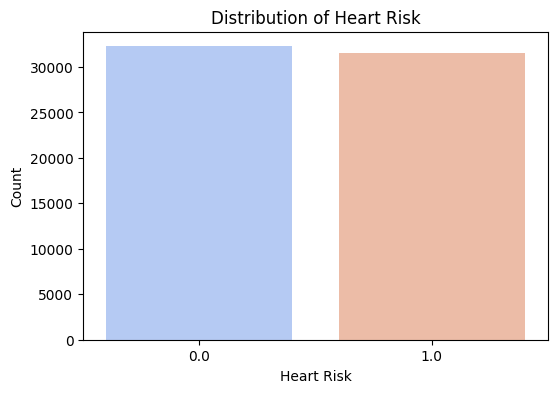

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Heart_Risk', data=df, palette='coolwarm')
plt.title('Distribution of Heart Risk')
plt.xlabel('Heart Risk')
plt.ylabel('Count')
plt.show()

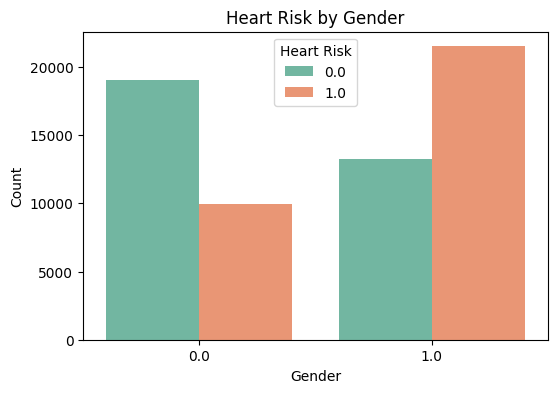

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Heart_Risk', data=df, palette='Set2')
plt.title('Heart Risk by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Heart Risk')
plt.show()

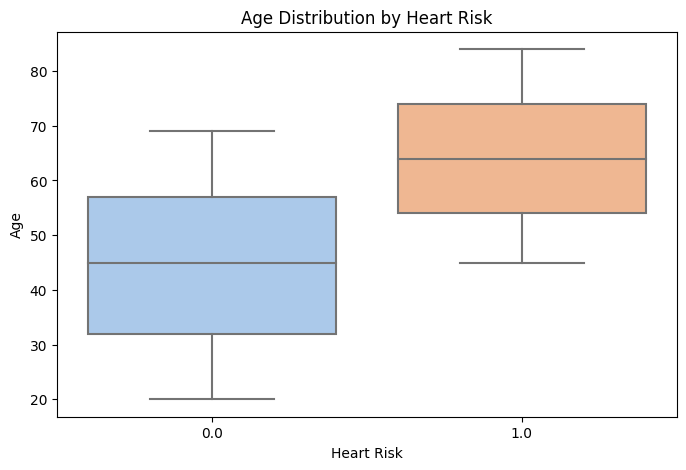

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Heart_Risk', y='Age', data=df, palette='pastel')
plt.title('Age Distribution by Heart Risk')
plt.xlabel('Heart Risk')
plt.ylabel('Age')
plt.show()

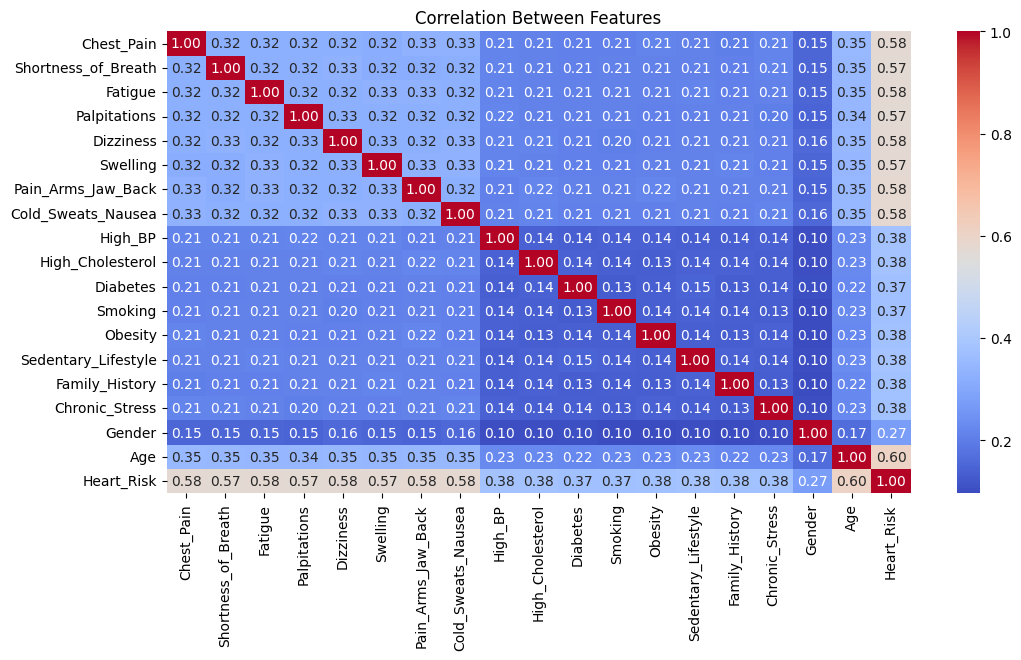

In [18]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Features')
plt.show()

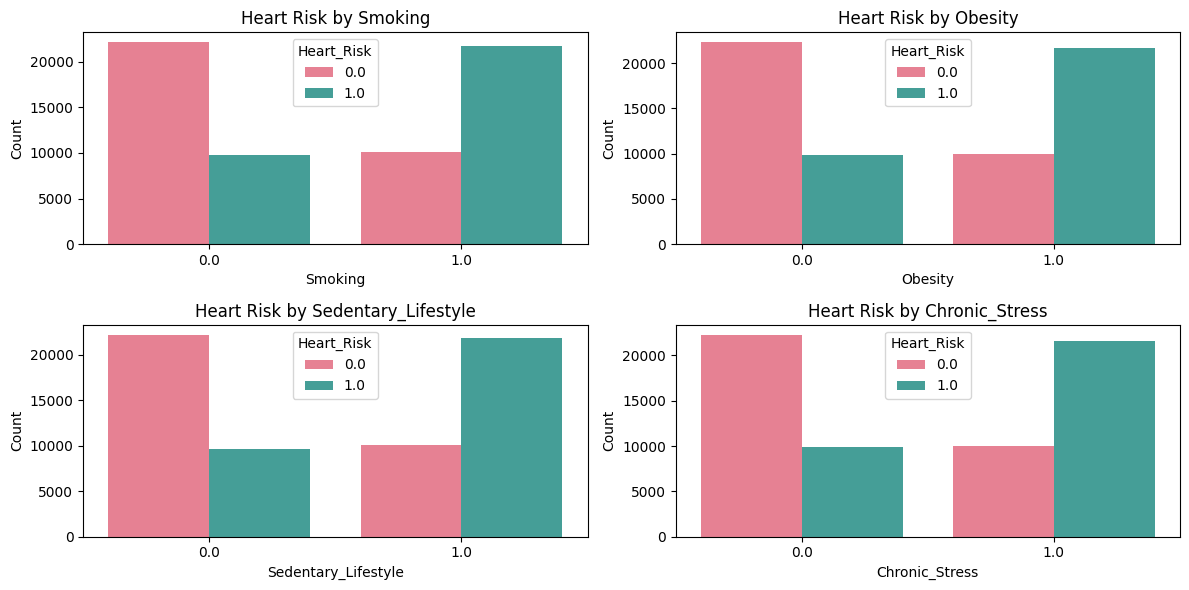

In [19]:
lifestyle_factors = ['Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Chronic_Stress']

plt.figure(figsize=(12, 6))
for i, col in enumerate(lifestyle_factors, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Heart_Risk', data=df, palette='husl')
    plt.title(f'Heart Risk by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

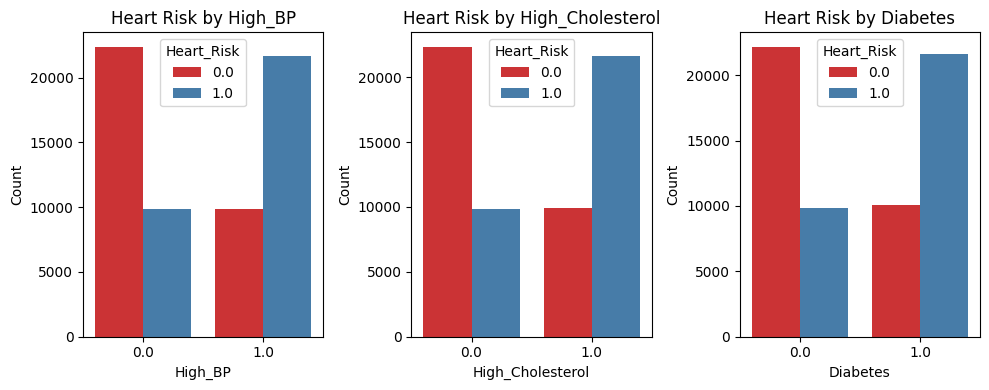

In [20]:
medical_conditions = ['High_BP', 'High_Cholesterol', 'Diabetes']

plt.figure(figsize=(10, 4))
for i, col in enumerate(medical_conditions, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue='Heart_Risk', data=df, palette='Set1')
    plt.title(f'Heart Risk by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

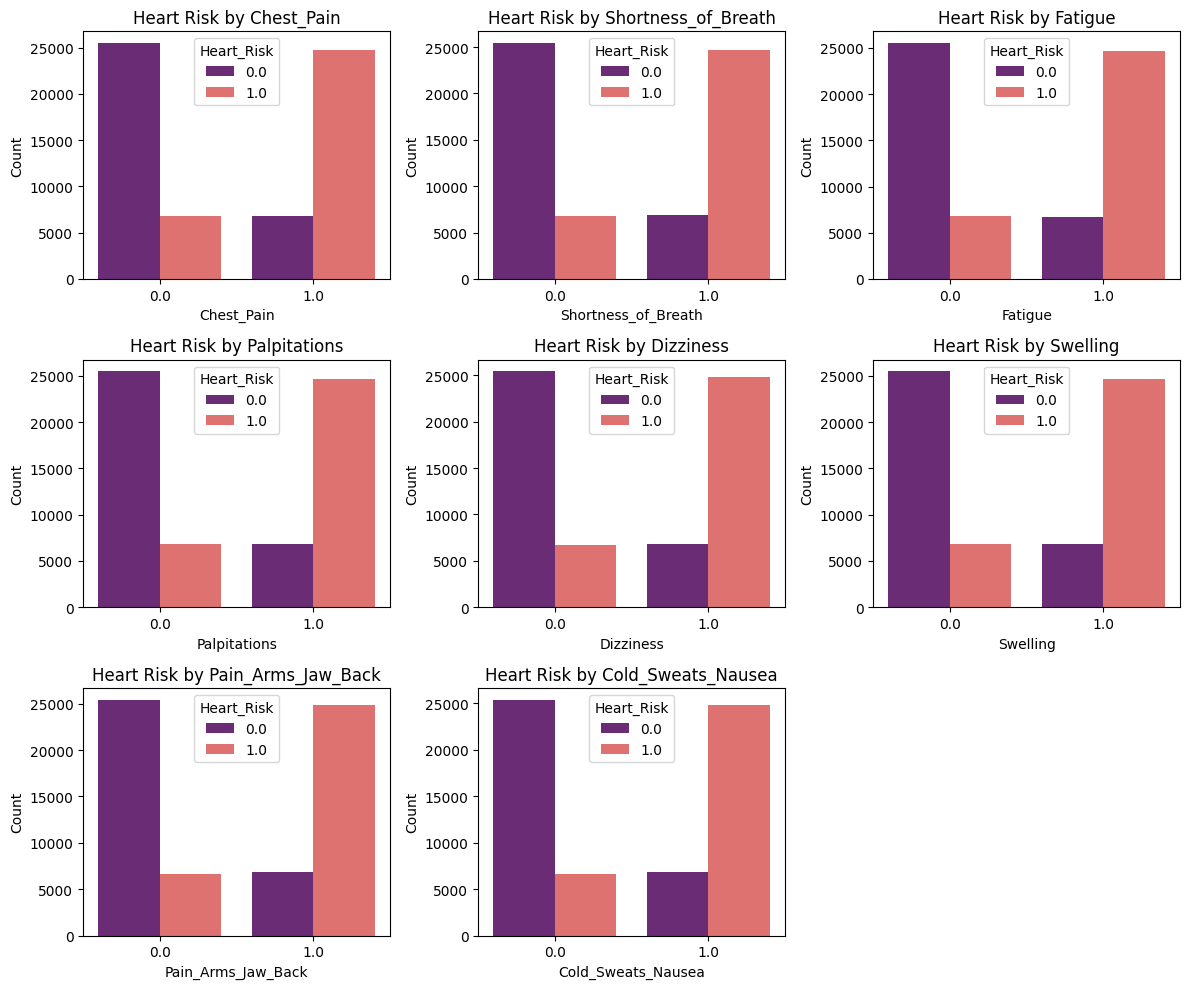

In [21]:
symptoms = ['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
            'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea']

plt.figure(figsize=(12, 10))
for i, col in enumerate(symptoms, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='Heart_Risk', data=df, palette='magma')
    plt.title(f'Heart Risk by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## EDA

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [23]:
df.dropna(inplace=True)  

In [24]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender']) 
df['Heart_Risk'] = le.fit_transform(df['Heart_Risk']) 

In [25]:
X = df.drop(columns=['Heart_Risk']) 
y = df['Heart_Risk']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train & evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Make predictions
    acc = accuracy_score(y_test, y_pred)  # Evaluate accuracy
    results[name] = acc
    print(f"📌 {name}: Accuracy = {acc:.4f}")

# Show results in a DataFrame
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
print(results_df)

📌 Logistic Regression: Accuracy = 0.9927
📌 Decision Tree: Accuracy = 0.9806
📌 Random Forest: Accuracy = 0.9934
📌 SVM: Accuracy = 0.9937
📌 XGBoost: Accuracy = 0.9927
                 Model  Accuracy
0  Logistic Regression  0.992706
1        Decision Tree  0.980629
2        Random Forest  0.993412
3                  SVM  0.993726
4              XGBoost  0.992706


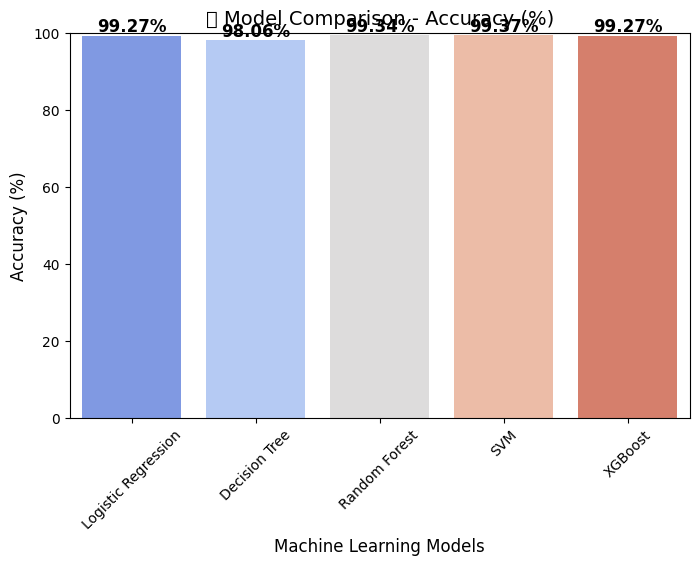

In [27]:
results_df['Accuracy (%)'] = results_df['Accuracy'] * 100  
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy (%)', data=results_df, palette='coolwarm')
for index, row in results_df.iterrows():
    plt.text(index, row['Accuracy (%)'] + 1, f"{row['Accuracy (%)']:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.title("🔍 Model Comparison - Accuracy (%)", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 100) 
plt.show()

## Thank you....pls upvote!!!!!!!